In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)

import_reload()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [34]:
RUN_ID = 'u_per_min10_2'
DT = 1
Q0 = 17921.57581 
SAVE  = False

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  3.0,
    's':  0.1
    }


VARIABLES = ['R0', 'R1', 'C1']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'µm'
    }
N_VAR = len(VARIABLES)

# Importing data

In [3]:
path = f'ecm_node_elements_0429_1012_staged_funcR0_unconstr_pulse_1.32min_32h_1000_0eps'

data = Param_symbol.read_data(path)

display(data.head())

N_TRAJS = len(data['trajectory'].unique())
print(f'Number of trajectories: {N_TRAJS}')

,trajectory,C,u_per,I,u,soc,R1,C1,R0,k
0,0,0.56,26.5,2.787801,-3.808911,1.000000,0.008427,774.54987,0.008969,3.212417
1,0,0.56,26.5,2.787801,-3.808911,0.999844,0.008426,774.55980,0.008969,3.212486
2,0,0.56,26.5,2.787801,-3.808911,0.999689,0.008426,774.56970,0.008969,3.212555
3,0,0.56,26.5,2.787801,-3.808911,0.999533,0.008426,774.57965,0.008969,3.212625
4,0,0.56,26.5,2.787801,-3.808911,0.999378,0.008426,774.58950,0.008969,3.212694


Number of trajectories: 100


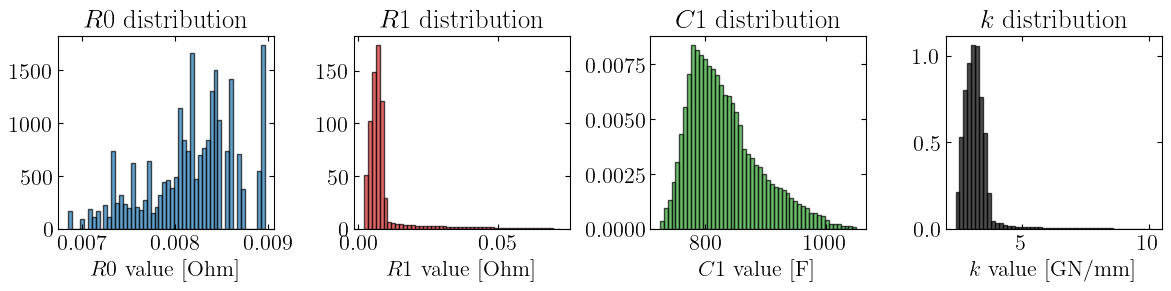

In [4]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()


In [5]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 1e6:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values / REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values / REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values / REF_VALUES['C1']
    Y_k  = d_frame['k'].values  / REF_VALUES['k']
    try:
        Y_s = d_frame['s'].values  / REF_VALUES['s']
    except KeyError:
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']

    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds],Y_R0[inds], Y_R1[inds], Y_C1[inds], Y_k[inds], Y_s[inds]

In [6]:
split_train = int(data['trajectory'].max() * 0.8)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)
else:

    data_train  = data[data['trajectory'] <= split_train]
    data_test   = data[data['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)

X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train = get_XY(data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test = get_XY(data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


No s column found, using reference value for all samples
Using every 1th data point for symbolic regression, total points: 155300
No s column found, using reference value for all samples
Using every 1th data point for symbolic regression, total points: 12604


In [7]:
# def print_models(df_model):
#     for i in range(len(df_model)):
#         print(f"Model {i}: Complexity={df_model['complexity'][i]}, Loss={df_model['loss'][i]}")
#         print(f"Equation: {df_model['equation'][i]}\n")

# def print_best_model(model, model_index = None):
#     best = model.get_best()
#     display(Math(f'\\LARGE {model.latex(model_index)}'))
#     display(Math(r'\LARGE $x_0 = \mathrm{{c}}$-rate$'))
#     display(Math(r'\LARGE $x_1 = \Delta u / L_{{tot}}$'))
#     display(Math(r'\LARGE $x_2 = \mathrm{SOC}$'))
#     print(f'Best model in symbolic form: {model.sympy()}\nLoss: {best["loss"]}\nBest model complexity: {best["complexity"]}')

In [8]:
# # Parity plot
# def pareto_plot(model):
#     df_model = model.equations_
#     best = model.get_best()
#     plt.grid(True, which="both", ls="-", linewidth=0.5)
#     plt.plot(df_model['complexity'], df_model['loss'], marker='o', linestyle='-', color=colors[0], label='Models')
#     plt.plot(best['complexity'], best['loss'],'o', color=colors[1], label='Best Model')
#     plt.xlabel('Complexity')
#     plt.ylabel('Loss')
#     plt.yscale('log')
#     plt.title('Model Complexity vs Loss')
#     plt.legend()
#     plt.show()

# def parity_plot(element,model, X_test = X_test, Yk_test = Yk_test, YC_test = YC_test, Y_R1_test = YR1_test):
#     if element == 'R1':
#         Y_test = YR1_test
#     elif element == 'k':
#         Y_test = Yk_test
#     elif element == 'C_1':
#         Y_test = YC_test

#     Y_pred = model.predict(X_test)
#     plt.scatter(Y_test, Y_pred, color=colors[0],alpha = 0.5)
#     plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2)
#     plt.xlabel(f'Actual ${element}$ [a.u.]')
#     plt.ylabel(f'Predicted ${element}$ [a.u.]')
#     plt.show()

# def save_expressions(df_model, element):
#     df_model.to_csv(f'sr_models/model_{element}.csv', index=False)

# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

In [9]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its  = 10)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [10]:
df_model_R0 = model_R0.equations_
Param_symbol.print_models(df_model_R0)

Model 0: Complexity=1, Loss=0.0017096533
Equation: 0.8260223

Model 1: Complexity=4, Loss=0.00057440135
Equation: sin(x0 ^ -0.103537016)

Model 2: Complexity=7, Loss=0.0004085551
Equation: tanh(cube((x1 / x0) ^ 0.028996741))

Model 3: Complexity=8, Loss=0.00031220465
Equation: tanh(cube((x1 / square(x0)) ^ 0.028996741))

Model 4: Complexity=10, Loss=0.00016123922
Equation: tanh(sqrt(sinh(cube((x1 / exp(x0)) ^ 0.043194044))))

Model 5: Complexity=12, Loss=7.052131e-05
Equation: tanh(sqrt(sinh(cube(((x1 / exp(x0)) + 0.14034924) ^ 0.04599284))))

Model 6: Complexity=14, Loss=6.33774e-05
Equation: tanh(sqrt(sinh(cube((((x2 + x0) + x1) / exp(x0)) ^ 0.04599284))))

Model 7: Complexity=15, Loss=5.5555436e-05
Equation: tanh(sqrt(sinh(cube((0.04599284 + ((tanh(x0) + x1) / exp(x0))) ^ 0.04599284))))



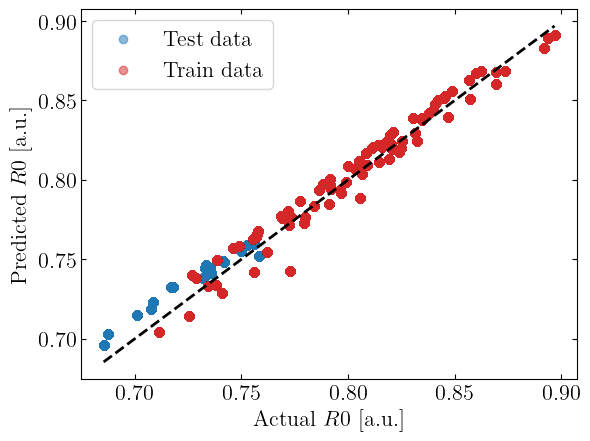

In [11]:
import_reload() 
Param_symbol.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

In [12]:
Param_symbol.print_best_model(model_R0)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: tanh(sqrt(sinh(((x1 + tanh(x0))*exp(-x0) + 0.04599284)**0.13797852)))
Loss: 5.5555436e-05
Best model complexity: 15


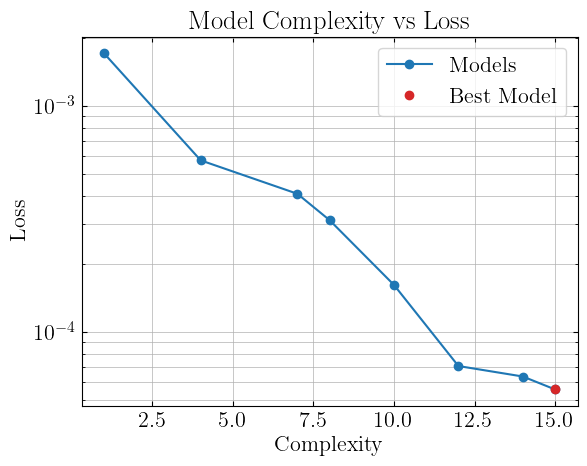

In [13]:
Param_symbol.pareto_plot(model_R0)

# $k = f_k(i,d,\mathrm{SOC})$

In [14]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its  = 10)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [15]:
df_model_k = model_k.equations_

In [16]:
Param_symbol.print_models(df_model_k)

Model 0: Complexity=1, Loss=0.039121
Equation: 1.0613892

Model 1: Complexity=3, Loss=0.038409576
Equation: 1.0339975 ^ x0

Model 2: Complexity=4, Loss=0.022334684
Equation: exp(0.49279404 ^ x1)

Model 3: Complexity=5, Loss=0.01886781
Equation: cosh(cos(x2) / x1)

Model 4: Complexity=7, Loss=0.013415749
Equation: exp((-0.4394936 / x1) * log(x2))

Model 5: Complexity=9, Loss=0.012485344
Equation: exp(exp(-0.012934958) / (square(exp(x2)) * x1))

Model 6: Complexity=10, Loss=0.012455993
Equation: exp(exp(x2 / -0.96028584) / (exp(x2) * x1))

Model 7: Complexity=11, Loss=0.012426454
Equation: exp(exp(x2 / 196.49306) / (square(exp(x2)) * x1))

Model 8: Complexity=12, Loss=0.012071471
Equation: exp(((0.308097 / x2) ^ x2) / (x1 * exp(sqrt(x2))))

Model 9: Complexity=13, Loss=0.011899342
Equation: exp(exp((x2 / sqrt(x0)) / -0.67347217) / (x1 * exp(x2)))

Model 10: Complexity=15, Loss=0.011885152
Equation: exp((exp((x2 / sqrt(x0)) / -0.6698752) / (exp(x2) * x1)) - -0.005133303)



In [17]:
Param_symbol.print_best_model(model_k)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 1.00514650097325*exp(exp(-x2)*exp(-1.49281537814805*x2/sqrt(x0))/x1)
Loss: 0.011885152
Best model complexity: 15


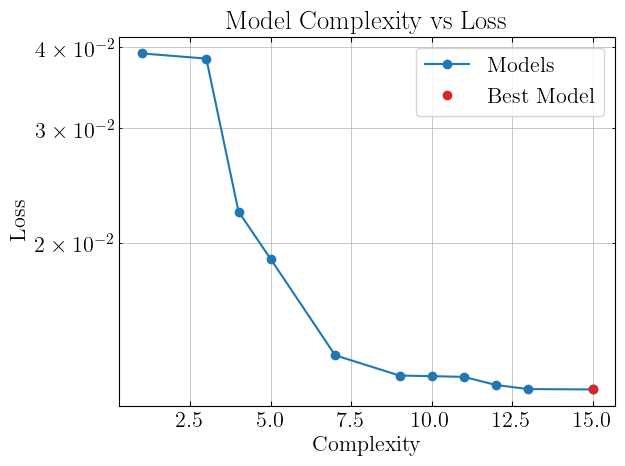

In [18]:
Param_symbol.pareto_plot(model_k)

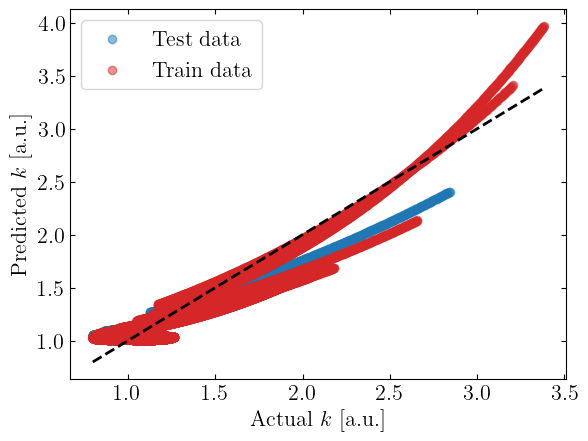

In [19]:
Param_symbol.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $R_1 = f_R(i,u,\mathrm{SOC})$

In [20]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = 10)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [21]:
df_model_R1 = model_R1.equations_

In [22]:
Param_symbol.print_models(df_model_R1)

Model 0: Complexity=1, Loss=0.9137595
Equation: 0.91826934

Model 1: Complexity=2, Loss=0.8766736
Equation: cos(x2)

Model 2: Complexity=3, Loss=0.25919747
Equation: 0.27671406 / x2

Model 3: Complexity=4, Loss=0.2410774
Equation: 0.27404347 / tanh(x2)

Model 4: Complexity=5, Loss=0.23102045
Equation: 0.27280217 / tanh(tanh(x2))

Model 5: Complexity=6, Loss=0.19851331
Equation: cube(x2) + (0.2596613 / x2)

Model 6: Complexity=8, Loss=0.18556829
Equation: cube(x2 / 1.120854) + (0.26278275 / x2)

Model 7: Complexity=9, Loss=0.1314164
Equation: ((0.0033856437 ^ x2) / (x2 + 0.08871718)) + x2

Model 8: Complexity=12, Loss=0.12581606
Equation: cube((tan(sinh(sinh(0.8322381 - tanh(x2)))) ^ 1.4322236) + x2)

Model 9: Complexity=13, Loss=0.1248474
Equation: square(cube(square(cos(x2 + x2)) ^ 2.5432167) / 0.43032545) + 0.6658428

Model 10: Complexity=14, Loss=0.09848952
Equation: x2 + square(sqrt(sinh(square(sinh(square(cos(x2 + x2))) ^ 3.0572128))))



In [23]:
Param_symbol.print_best_model(model_R1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: x2 + sinh(sinh(cos(2*x2)**2)**6.1144256)
Loss: 0.09848952
Best model complexity: 14


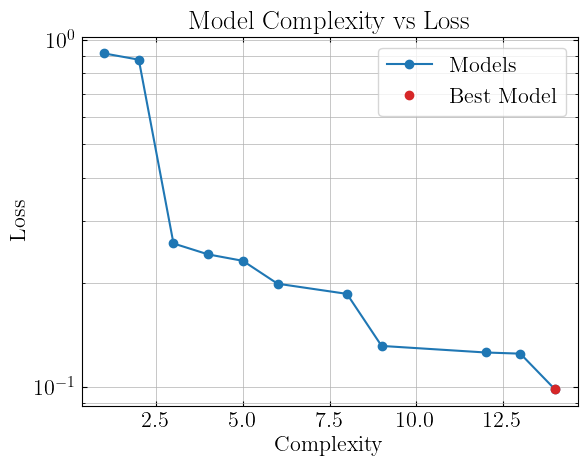

In [24]:
Param_symbol.pareto_plot(model_R1)

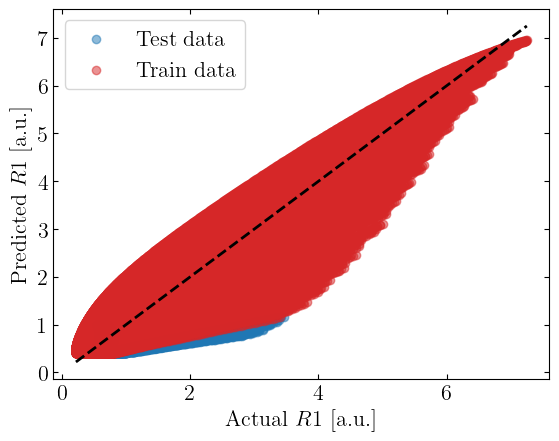

In [25]:
Param_symbol.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

In [26]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = 10)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [27]:
df_model_C1 = model_C1.equations_

In [28]:
Param_symbol.print_models(df_model_C1)

Model 0: Complexity=1, Loss=0.003419603
Equation: 0.8364433

Model 1: Complexity=4, Loss=0.001870054
Equation: sqrt(x1 ^ -0.14527635)

Model 2: Complexity=6, Loss=0.0015563383
Equation: sqrt((x1 + x0) ^ -0.13748924)

Model 3: Complexity=7, Loss=0.0005297838
Equation: sqrt(sin((x2 * x1) ^ -0.15568402))

Model 4: Complexity=10, Loss=0.0004633664
Equation: sqrt(((x2 + x2) * (x0 + x1)) ^ -0.14716898)

Model 5: Complexity=14, Loss=0.00045138592
Equation: sqrt(((x0 + x1) * (x2 + ((x2 ^ x2) * x2))) ^ -0.1492914)



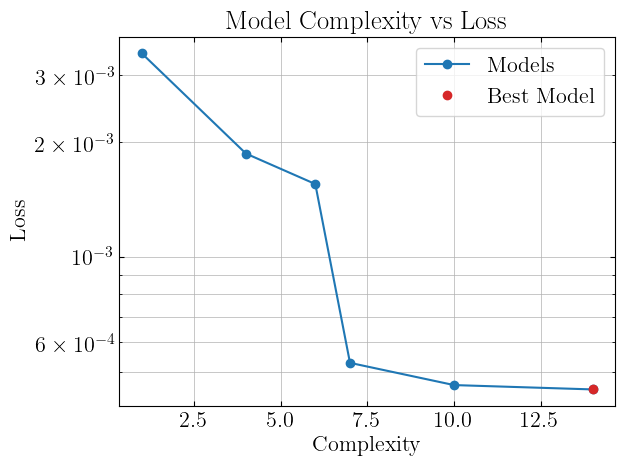

In [29]:
Param_symbol.pareto_plot(model_C1)

In [30]:
Param_symbol.print_best_model(model_C1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: ((x0 + x1)*(x2*x2**x2 + x2))**(-0.0746457)
Loss: 0.00045138592
Best model complexity: 14


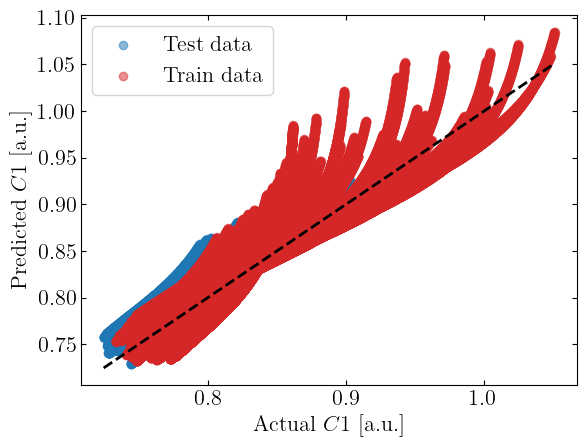

In [32]:
Param_symbol.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

In [33]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k
}

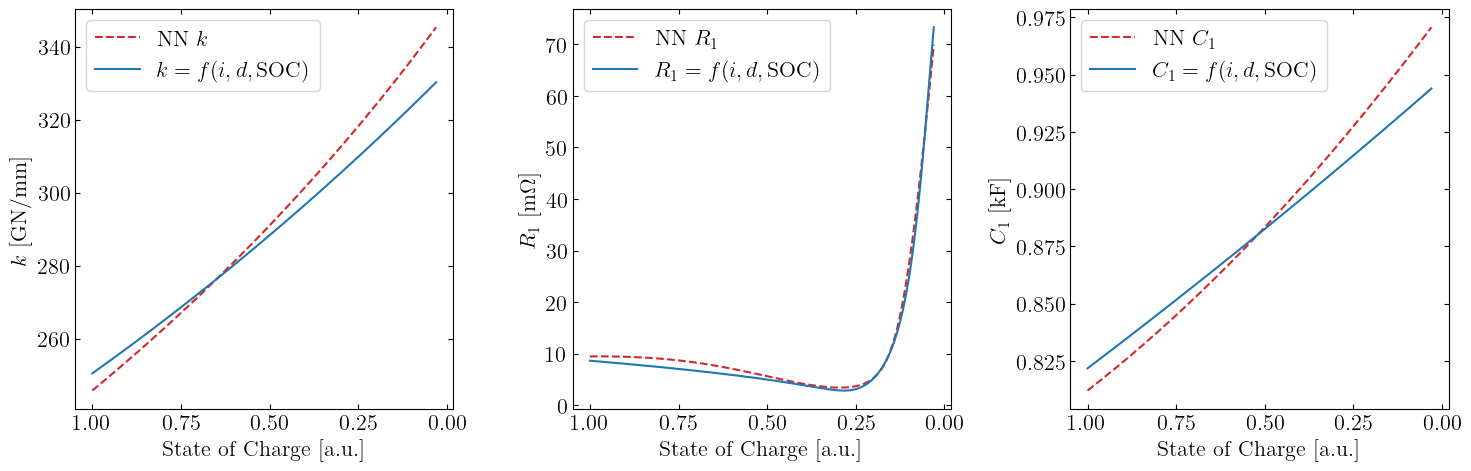

In [ ]:
def plot_trajs_SOC(data = data, ind = 0, modelR = model_R1, modelC = model_C1,model_0 = model_k, test = False):
    tr = prepare_data(data, index = ind, test=test)
    X = tr[['C', 'u_per', 'soc']].values
    Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
    YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
    YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
    f,ax = plt.subplots(1,3, figsize=(15,5))
    ax[0].plot(tr['soc'], tr['k'] * 100, label=r'NN $k$',  color=colors[1], linestyle='--')
    ax[0].plot(tr['soc'], Yk_pred, label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
    ax[1].plot(tr['soc'], tr['R1'] * 1000, label=r'NN $R_1$',  color=colors[1], linestyle='--')
    ax[1].plot(tr['soc'], YR1_pred, label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
    ax[2].plot(tr['soc'], tr['C1'] / 1000, label=r'NN $C_1$', color=colors[1], linestyle='--')
    ax[2].plot(tr['soc'], YC_pred, label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
    for a in ax:
        a.set_xlabel('State of Charge [a.u.]')
        a.legend()
        a.invert_xaxis()
    ax[0].set_ylabel(r'$k$ [GN/mm]');ax[2].set_ylabel(r'$C_1$ [kF]');ax[1].set_ylabel(r'$R_1$ [m$\Omega$]') 

    plt.tight_layout()
    plt.savefig('symbolic_traj_test.pdf')

plot_trajs_SOC(test = False, ind = 4)

ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required.

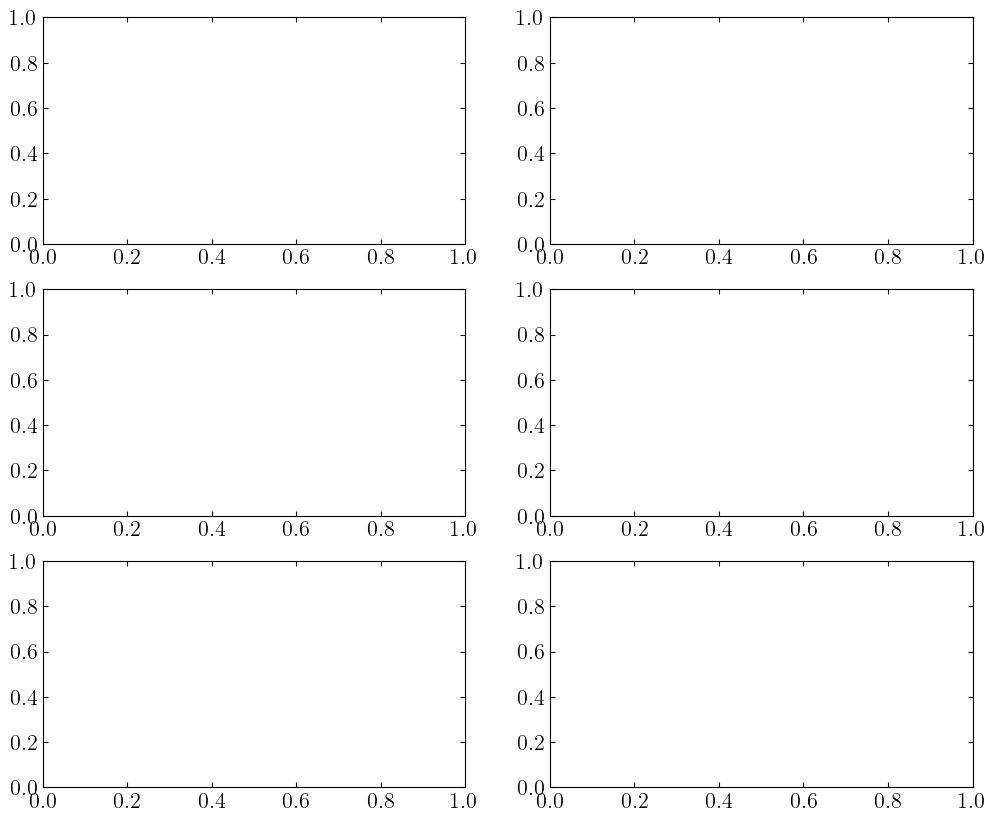

In [ ]:
def plot_trajs_C_d(data = data, modelR = model_R1, modelC = model_C1,model_0 = model_k, test = False):
    f,axs = plt.subplots(3,2, figsize=(12,10))
    
    train_index = int(0.8 * N_TRAJS )
    test_index = int(N_TRAJS - train_index)
    if test:
        ind = test_index
    else:
        ind = train_index
    i=0
    k_pred = np.zeros((ind,3)); R1_pred = np.zeros((ind,3)); C1_pred = np.zeros((ind,3))
    k_true = np.zeros((ind,3)); R1_true = np.zeros((ind,3)); C1_true = np.zeros((ind,3))
    X_vals = np.zeros((ind,2))    
    while i < ind:
        tr = prepare_data(data, index = i, test=test)
        X = tr[['C', 'u_per', 'soc']].values
        Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
        YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
        YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
        
        k_pred[i,0] = Yk_pred.mean(); R1_pred[i,0] = YR1_pred.mean(); C1_pred[i,0] = YC_pred.mean()
        k_pred[i,1] = Yk_pred.min(); R1_pred[i,1] = YR1_pred.min(); C1_pred[i,1] = YC_pred.min()
        k_pred[i,2] = Yk_pred.max(); R1_pred[i,2] = YR1_pred.max(); C1_pred[i,2] = YC_pred.max()

        k_true[i,0] = tr['k'].mean() * 100; R1_true[i,0] = tr['R1'].mean() * 1000; C1_true[i,0] = tr['C1'].mean() / 1000
        k_true[i,1] = tr['k'].min() * 100; R1_true[i,1] = tr['R1'].min() * 1000; C1_true[i,1] = tr['C1'].min() / 1000
        k_true[i,2] = tr['k'].max() * 100; R1_true[i,2] = tr['R1'].max() * 1000; C1_true[i,2] = tr['C1'].max() / 1000
        X_vals[i,0] = X[0,0]; X_vals[i,1] = X[0,1]
        i += 1

    for j in range(len(axs[0,:])):
        ax = axs[:,j]
        x = X_vals[:,j]
        ax[0].scatter(x, k_pred[:,0], label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
        ax[0].scatter(x, k_true[:,0], label=r'NN $k$',  color=colors[1], alpha=0.7)
        #ax[0].plot(x, k_true[:,1] * X_vals[:,1], color=colors[1], alpha=0.7, linestyle='--')
        #ax[0].plot(x, k_true[:,2] * X_vals[:,1], color=colors[1], alpha=0.7, linestyle='--')
        #ax[0].fill_between(x, k_true[:,1] * X_vals[:,1], k_true[:,2] * X_vals[:,1], color=colors[1], alpha=0.2, label='NN range')
        #ax[1].fill_between(x, R1_true[:,1] , R1_true[:,2], color=colors[1], alpha=0.2, label='NN range')
        #ax[2].fill_between(x, C1_true[:,1], C1_true[:,2], color=colors[1], alpha=0.2, label='NN range')

        ax[1].scatter(x, R1_pred[:,0], label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
        ax[1].scatter(x, R1_true[:,0], label=r'NN $R_1$',  color=colors[1], alpha=0.7)
        ax[2].scatter(x, C1_pred[:,0], label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
        ax[2].scatter(x, C1_true[:,0], label=r'NN $C_1$', color=colors[1], alpha=0.7)
        ax[0].set_ylabel(r'$k$ [GN/mm]');ax[2].set_ylabel(r'$C_1$ [kF]');ax[1].set_ylabel(r'$R_1$ [m$\Omega$]') 
        
        ax[0].legend(); ax[1].legend(); ax[2].legend()
    for a in axs[:,0]:
        a.set_xlabel('C-rate [a.u.]')
    for a in axs[:,1]:
        a.set_xlabel(r'$\Delta u / L_{tot}$ [a.u.]')
    # for tr in test_trajs:
    #     X = tr[['C', 'u_per', 'soc']].values
    #     Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
    #     YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
    #     YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
    #     f,ax = plt.subplots(1,3, figsize=(15,5))
    #     ax[0].plot(tr['C'], tr['k'] * 100, label=r'NN $k$',  color=colors[1], linestyle='--')
    #     ax[0].plot(tr['C'], Yk_pred, label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
    #     ax[1].plot(tr['C'], tr['R1'] * 1000, label=r'NN $R_1$',  color=colors[1], linestyle='--')
    #     ax[1].plot(tr['C'], YR1_pred, label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
    #     ax[2].plot(tr['C'], tr['C1'] / 1000, label=r'NN $C_1$', color=colors[1], linestyle='--')
    #     ax[2].plot(tr['C'], YC_pred, label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
    #     for a in ax:
    #         a.set_xlabel('C-rate [a.u.]')
    #         a.legend()
    #         a.invert_xaxis()
        
            
         
    plt.tight_layout()

    plt.show()
    f,ax = plt.subplots(1,3, figsize=(15,4))
    ax[0].scatter(X_vals[:,0],X_vals[:,1],c= k_pred[:,0], label=r'$k = f(i,d,\mathrm{SOC})$',cmap = 'Blues')
    ax[0].set_xlabel('C-rate [a.u.]')
    ax[0].set_ylabel(r'$k$ [GN/mm]')
    ax[0].legend()
    ax[1].scatter(X_vals[:,0],X_vals[:,1],c= R1_pred[:,0], label=r'$R_1 = f(i,d,\mathrm{SOC})$',cmap = 'Greens')
    ax[1].set_xlabel('C-rate [a.u.]')
    ax[1].set_ylabel(r'$R_1$ [m$\Omega$]')
    ax[1].legend()
    ax[2].scatter(X_vals[:,0],X_vals[:,1],c= C1_pred[:,0], label=r'$C_1 = f(i,d,\mathrm{SOC})$',cmap = 'Oranges')
    ax[2].set_xlabel('C-rate [a.u.]')
    ax[2].set_ylabel(r'$C_1$ [kF]')
    ax[2].legend()
    plt.tight_layout()

plot_trajs_C_d(test = False)

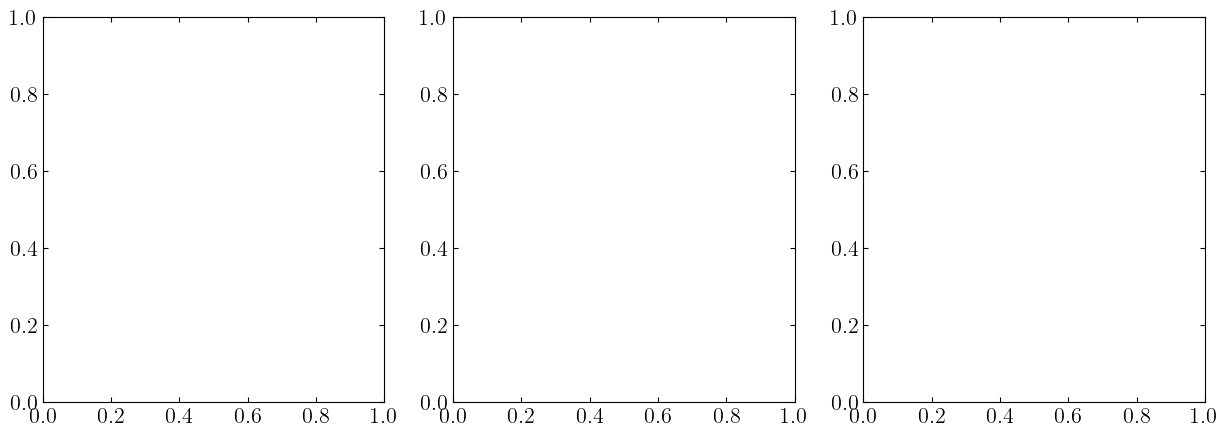

In [ ]:
f,ax = plt.subplots(1,3, figsize=(15,5))

In [ ]:
if SAVE:
    save_expressions(df_model_k,  f'k_{RUN_ID}')
    save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    save_expressions(df_model_R1, f'R1_{RUN_ID}')
    save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    save_expressions(df_model_C1, f'C1_{RUN_ID}')
    save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')